In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [16]:
# ----------------------------
# 0) CONFIG F2
# ----------------------------

# Data paths (NO augmented files)
INPUTS_PATH = "data/F2/initial_inputs.npy"
OUTPUTS_PATH = "data/F2/initial_outputs.npy"

# Search space (F2 is defined on [0,1]²)
BOUNDS = np.array([
    [0.0, 1.0],  # x1
    [0.0, 1.0],  # x2
])

# Optimisation direction
MAXIMIZE = True          # F2: maximize log-likelihood

# Acquisition parameters
XI = 0.03                # higher than F1 → more exploration (noisy function)
KAPPA = 2.0              # only used if UCB is selected

# Candidate search
N_CAND_GLOBAL = 30000    # global exploration
N_CAND_LOCAL = 20000     # local search near current best

# Batch selection
BATCH_SIZE = 5           # number of points to submit this week
MIN_DIST = 0.03          # diversity constraint

# Reproducibility
RANDOM_SEED = 7

In [17]:
# ----------------------------
# 1) LOAD DATA F2 - Arrays directly
# ----------------------------
X = np.load(INPUTS_PATH).astype(float)
y = np.load(OUTPUTS_PATH).astype(float).reshape(-1,)

if X.ndim != 2 or X.shape[1] != 2:
    raise ValueError(f"Expected X shape (n,2). Got {X.shape}")

if y.shape[0] != X.shape[0]:
    raise ValueError(f"X and y size mismatch: {X.shape[0]} vs {y.shape[0]}")

print("\nF2 SHAPE - Inputs:", X.shape, "Outputs:", y.shape)
print("Last values - input:", X[-1:], "output:", y[-1:])


F2 SHAPE - Inputs: (12, 2) Outputs: (12,)
Last values - input: [[0.3125 1.    ]] output: [-0.06729794]


In [18]:
# ============================================================
# 2) Bounds (F2 is in [0,1] typically; use global unless told otherwise)
# ============================================================
bounds = np.array([[0.0, 1.0],
                   [0.0, 1.0]], dtype=float)


In [19]:
# ============================================================
# 3) Normal PDF/CDF helpers (no SciPy)
# ============================================================
def std_norm_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2.0 * np.pi)

def approx_erf(x):
    sign = np.sign(x)
    x = np.abs(x)
    t = 1.0 / (1.0 + 0.3275911 * x)
    a1, a2, a3, a4, a5 = 0.254829592, -0.284496736, 1.421413741, -1.453152027, 1.061405429
    y = 1.0 - (((((a5 * t + a4) * t) + a3) * t + a2) * t + a1) * t * np.exp(-x * x)
    return sign * y

def std_norm_cdf(z):
    return 0.5 * (1.0 + approx_erf(z / np.sqrt(2.0)))

In [20]:
# ============================================================
# 4) Surrogates + uncertainty (F2: noisy -> include WhiteKernel & ensembles)
# ============================================================
def fit_gp(X, y):
    # Good default for 2D noisy functions
    kernel = (
        C(1.0, (1e-3, 1e3))
        * Matern(length_scale=np.ones(2), nu=2.5)
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e0))
    )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=8,
        random_state=0
    )
    model = Pipeline([("scaler", StandardScaler()), ("gp", gp)])
    model.fit(X, y)
    return model

def gp_predict(model, Xcand):
    Xs = model.named_steps["scaler"].transform(Xcand)
    mu, std = model.named_steps["gp"].predict(Xs, return_std=True)
    std = np.maximum(std, 1e-9)
    return mu, std

def fit_rf_ensemble(X, y, n_models=20):
    models = []
    for s in range(n_models):
        m = RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=2,
            bootstrap=True,
            n_jobs=-1,
            random_state=1000 + s
        )
        m.fit(X, y)
        models.append(m)
    return models

def fit_gbm_ensemble(X, y, n_models=20):
    models = []
    for s in range(n_models):
        m = GradientBoostingRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9,
            random_state=2000 + s
        )
        m.fit(X, y)
        models.append(m)
    return models

def ensemble_predict(models, Xcand):
    preds = np.stack([m.predict(Xcand) for m in models], axis=0)
    mu = preds.mean(axis=0)
    std = preds.std(axis=0, ddof=1)
    std = np.maximum(std, 1e-9)
    return mu, std

gp_model = fit_gp(X, y)
rf_models = fit_rf_ensemble(X, y, n_models=20)
gbm_models = fit_gbm_ensemble(X, y, n_models=20)

print("Trained: GP + RF ensemble + GBM ensemble")


Trained: GP + RF ensemble + GBM ensemble


In [21]:
# ============================================================
# 5) Acquisition (Expected Improvement + optional UCB)
# ============================================================
def expected_improvement(mu, sigma, y_best, xi=0.02):
    imp = mu - y_best - xi
    z = imp / sigma
    return imp * std_norm_cdf(z) + sigma * std_norm_pdf(z)

def ucb(mu, sigma, kappa=2.0):
    return mu + kappa * sigma

In [22]:
# ============================================================
# 6) Candidate generation (global + local around best)
#    F2: you likely want to probe around high region AND still explore.
# ============================================================
def sample_uniform(n, bounds, rng):
    d = bounds.shape[0]
    u = rng.random((n, d))
    return bounds[:, 0] + u * (bounds[:, 1] - bounds[:, 0])

def sample_local(x_center, n, bounds, rng, radius=0.08):
    d = bounds.shape[0]
    Xl = x_center + rng.normal(scale=radius, size=(n, d))
    for j in range(d):
        Xl[:, j] = np.clip(Xl[:, j], bounds[j, 0], bounds[j, 1])
    return Xl

def propose_next_batch(
    X, y, bounds,
    batch_size=5,
    model_kind="gp",     # "gp" | "rf" | "gbm"
    acq_kind="ei",       # "ei" | "ucb"
    n_global=30000,
    n_local=20000,
    xi=0.02,
    kappa=2.0,
    min_dist=0.03,
    seed=42
):
    rng = np.random.default_rng(seed)

    # pick predictor
    if model_kind == "gp":
        pred = lambda Xc: gp_predict(gp_model, Xc)
    elif model_kind == "rf":
        pred = lambda Xc: ensemble_predict(rf_models, Xc)
    elif model_kind == "gbm":
        pred = lambda Xc: ensemble_predict(gbm_models, Xc)
    else:
        raise ValueError("model_kind must be: gp, rf, gbm")

    best_i = int(np.argmax(y))
    x_best = X[best_i]
    y_best = float(y[best_i])

    Xcand = np.vstack([
        sample_uniform(n_global, bounds, rng),
        sample_local(x_best, n_local, bounds, rng, radius=0.08)
    ])

    mu, std = pred(Xcand)

    if acq_kind == "ei":
        acq = expected_improvement(mu, std, y_best=y_best, xi=xi)
    elif acq_kind == "ucb":
        acq = ucb(mu, std, kappa=kappa)
    else:
        raise ValueError("acq_kind must be: ei, ucb")

    order = np.argsort(-acq)

    chosen = []
    for idx in order:
        x = Xcand[idx]

        # distance from existing points
        if np.min(np.linalg.norm(X - x, axis=1)) < min_dist:
            continue
        # distance within batch
        if chosen and np.min(np.linalg.norm(np.array(chosen) - x, axis=1)) < min_dist:
            continue

        chosen.append(x)
        if len(chosen) == batch_size:
            break

    # relax if needed
    if len(chosen) < batch_size:
        min_dist2 = 0.5 * min_dist
        for idx in order:
            x = Xcand[idx]
            if np.min(np.linalg.norm(X - x, axis=1)) < min_dist2:
                continue
            if chosen and np.min(np.linalg.norm(np.array(chosen) - x, axis=1)) < min_dist2:
                continue
            chosen.append(x)
            if len(chosen) == batch_size:
                break

    return np.array(chosen), {"x_best": x_best, "y_best": y_best}

next_X, info = propose_next_batch(
    X, y, bounds,
    batch_size=5,     # change to whatever your prof wants
    model_kind="gp",  # EI + GP is a strong default for noisy 2D
    acq_kind="ei",
    xi=0.03,          # slightly more exploration under noise
    min_dist=0.03,
    seed=7
)

print("Current best:", info["y_best"], "at", info["x_best"])
print("\nNEXT POINTS TO SUBMIT:\n", next_X)

# Save for submission
np.save("next_inputs.npy", next_X)
print("Saved -> next_inputs.npy")


Current best: 0.6112052157614438 at [0.70263656 0.9265642 ]

NEXT POINTS TO SUBMIT:
 [[0.96836293 0.55728772]
 [0.96837481 0.0863455 ]
 [0.96823419 0.45942762]
 [0.96820794 0.68992715]
 [0.96819705 0.39655002]]
Saved -> next_inputs.npy


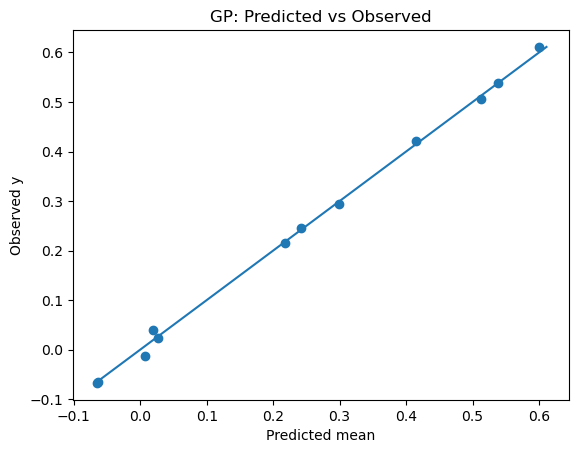

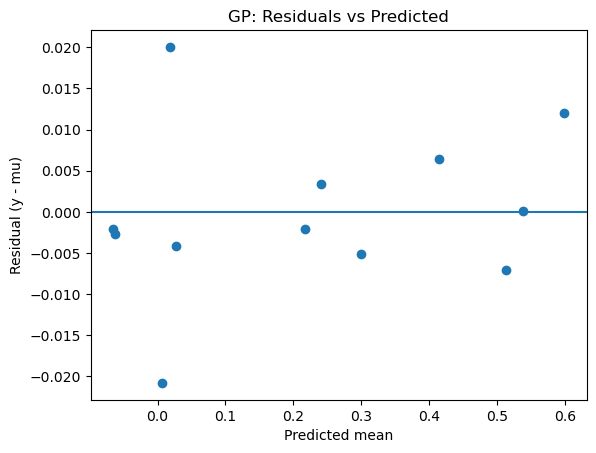

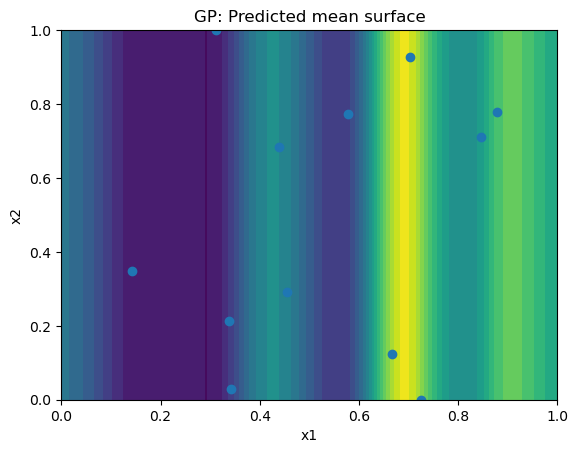

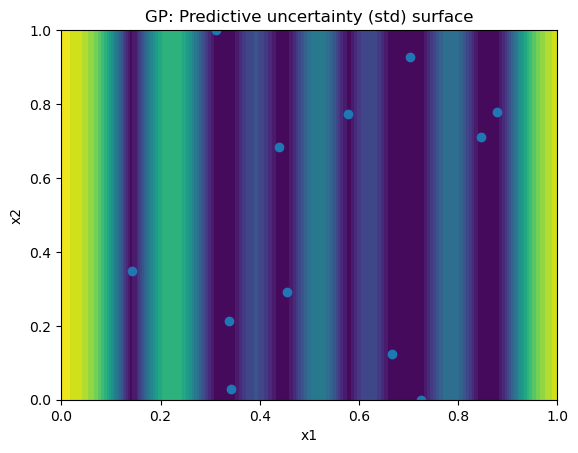

[GP] train x1 range: (np.float64(0.14269907423594608), np.float64(0.8777909889953304))
[GP] train x2 range: (np.float64(0.0), np.float64(1.0))
[GP] next  x1 range: (np.float64(0.9681970504340308), np.float64(0.9683748055516794))
[GP] next  x2 range: (np.float64(0.08634549660475777), np.float64(0.6899271476941629))


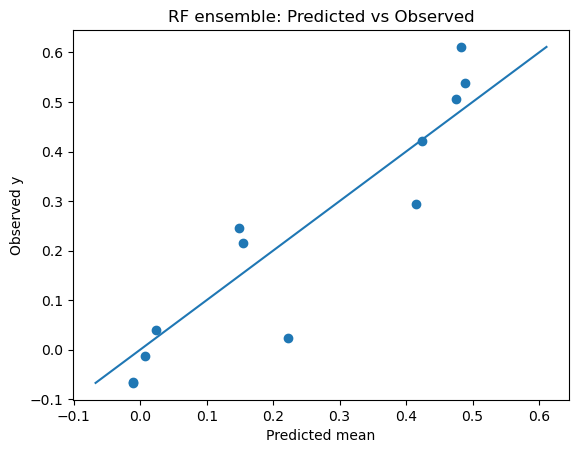

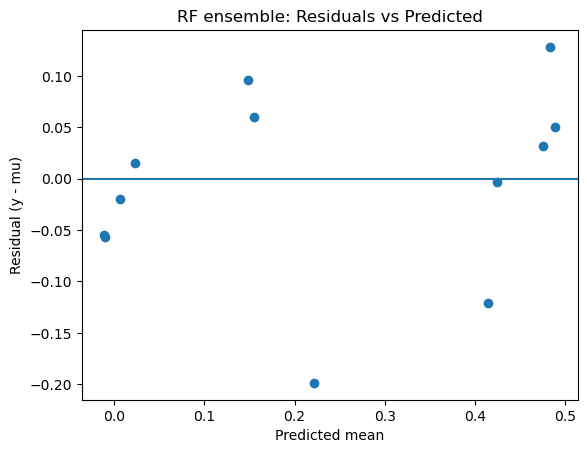

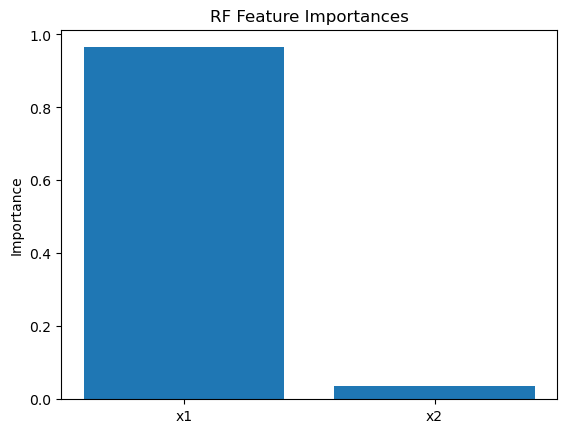

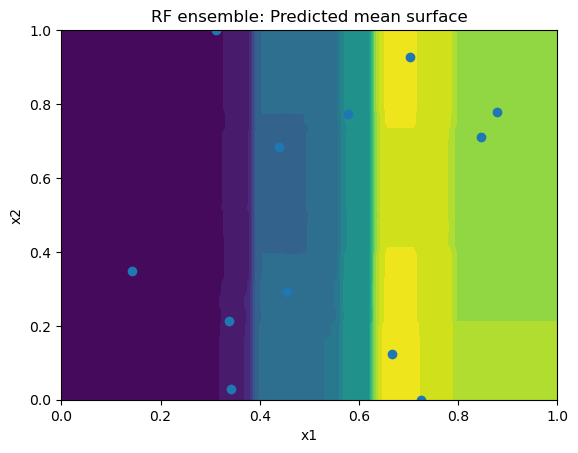

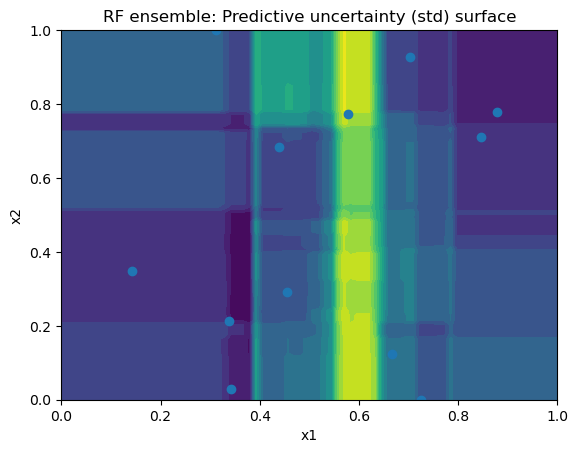

[RF ensemble] train x1 range: (np.float64(0.14269907423594608), np.float64(0.8777909889953304))
[RF ensemble] train x2 range: (np.float64(0.0), np.float64(1.0))
[RF ensemble] next  x1 range: (np.float64(0.9681970504340308), np.float64(0.9683748055516794))
[RF ensemble] next  x2 range: (np.float64(0.08634549660475777), np.float64(0.6899271476941629))


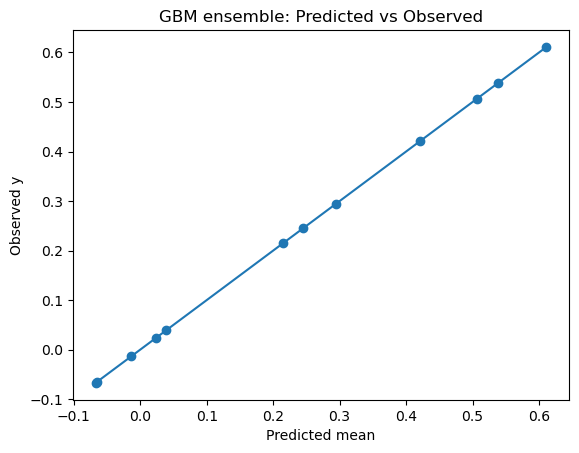

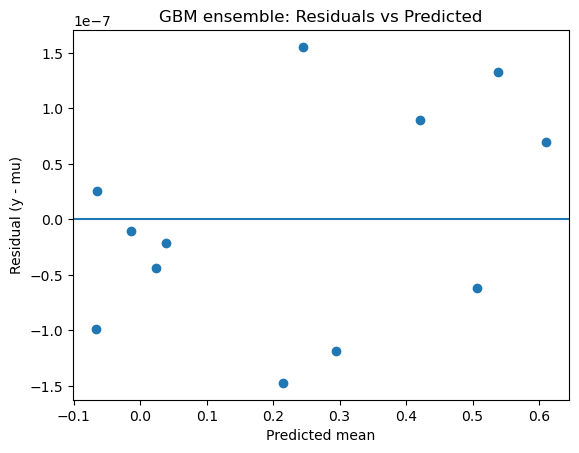

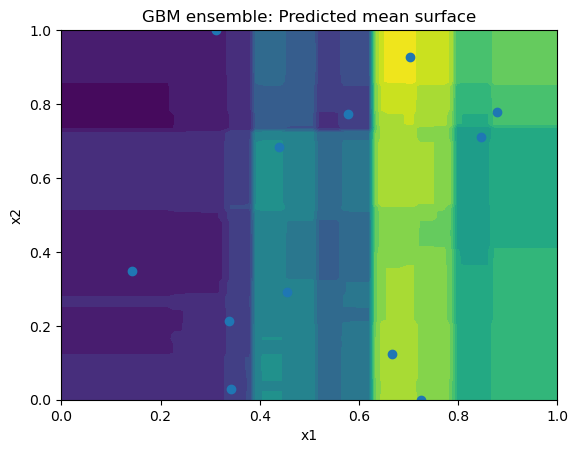

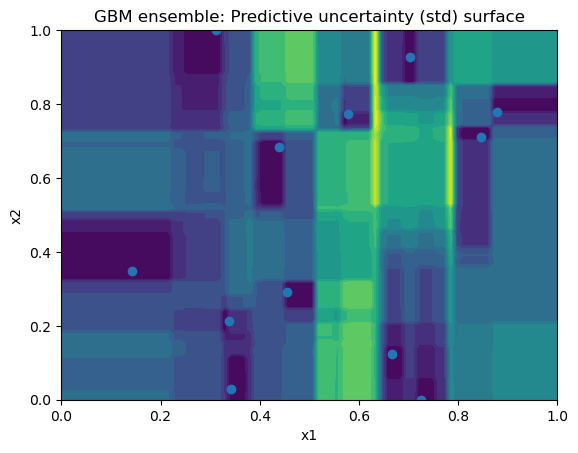

[GBM ensemble] train x1 range: (np.float64(0.14269907423594608), np.float64(0.8777909889953304))
[GBM ensemble] train x2 range: (np.float64(0.0), np.float64(1.0))
[GBM ensemble] next  x1 range: (np.float64(0.9681970504340308), np.float64(0.9683748055516794))
[GBM ensemble] next  x2 range: (np.float64(0.08634549660475777), np.float64(0.6899271476941629))


In [23]:
# ============================================================
# 7) Diagnostics (Week 3 checklist)
# ============================================================
def diagnostics(model_kind="gp", grid_n=80):
    if model_kind == "gp":
        pred = lambda Xc: gp_predict(gp_model, Xc)
        label = "GP"
    elif model_kind == "rf":
        pred = lambda Xc: ensemble_predict(rf_models, Xc)
        label = "RF ensemble"
    elif model_kind == "gbm":
        pred = lambda Xc: ensemble_predict(gbm_models, Xc)
        label = "GBM ensemble"
    else:
        raise ValueError

    # predicted vs observed
    mu, std = pred(X)
    resid = y - mu

    plt.figure()
    plt.scatter(mu, y)
    mn, mx = min(mu.min(), y.min()), max(mu.max(), y.max())
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Predicted mean")
    plt.ylabel("Observed y")
    plt.title(f"{label}: Predicted vs Observed")
    plt.show()

    plt.figure()
    plt.scatter(mu, resid)
    plt.axhline(0.0)
    plt.xlabel("Predicted mean")
    plt.ylabel("Residual (y - mu)")
    plt.title(f"{label}: Residuals vs Predicted")
    plt.show()

    # feature importances (RF only)
    if model_kind == "rf":
        imp = rf_models[0].feature_importances_
        plt.figure()
        plt.bar(["x1", "x2"], imp)
        plt.ylabel("Importance")
        plt.title("RF Feature Importances")
        plt.show()

    # 2D mean & uncertainty maps
    x1 = np.linspace(bounds[0,0], bounds[0,1], grid_n)
    x2 = np.linspace(bounds[1,0], bounds[1,1], grid_n)
    X1, X2 = np.meshgrid(x1, x2)
    grid = np.column_stack([X1.ravel(), X2.ravel()])

    mu_g, std_g = pred(grid)
    MU = mu_g.reshape(grid_n, grid_n)
    SD = std_g.reshape(grid_n, grid_n)

    plt.figure()
    plt.contourf(X1, X2, MU, levels=20)
    plt.scatter(X[:,0], X[:,1])
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.title(f"{label}: Predicted mean surface")
    plt.show()

    plt.figure()
    plt.contourf(X1, X2, SD, levels=20)
    plt.scatter(X[:,0], X[:,1])
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.title(f"{label}: Predictive uncertainty (std) surface")
    plt.show()

    # quick “stuck region?” check
    print(f"[{label}] train x1 range:", (X[:,0].min(), X[:,0].max()))
    print(f"[{label}] train x2 range:", (X[:,1].min(), X[:,1].max()))
    print(f"[{label}] next  x1 range:", (next_X[:,0].min(), next_X[:,0].max()))
    print(f"[{label}] next  x2 range:", (next_X[:,1].min(), next_X[:,1].max()))

diagnostics("gp")
diagnostics("rf")
diagnostics("gbm")

In [24]:
# ----------------------------
# FINAL SUBMISSION POINT (Week 03 – F2)
# ----------------------------
X_submit = next_X[:1]

print("Final X to submit:")
print(X_submit)

np.save("X_submit.npy", X_submit)


Final X to submit:
[[0.96836293 0.55728772]]
